/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:72: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

  0%|          | 0/562 [00:00<?, ?it/s]

Epoch 9/10 - Training Loss: 0.0038, Validation Loss: 0.1562


  0%|          | 0/2245 [00:00<?, ?it/s]

  0%|          | 0/562 [00:00<?, ?it/s]

Epoch 10/10 - Training Loss: 0.0032, Validation Loss: 0.1716


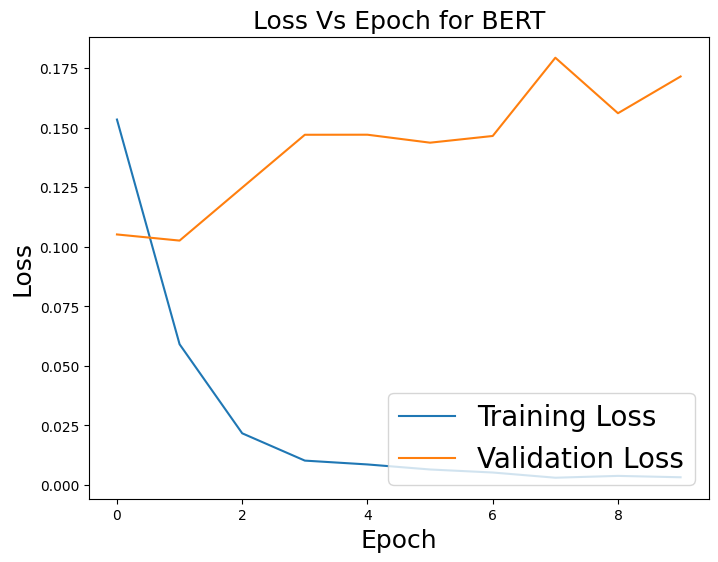

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
from transformers import BertForSequenceClassification, BertTokenizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score, precision_score, recall_score
from tqdm.notebook import tqdm
from torch.optim import Adam
import matplotlib.pyplot as plt



class FakeNewsDataset(Dataset):
    def __init__(self, mode, tokenizer, path):
        assert mode in ['train', 'test']
        self.mode = mode
        self.df = pd.read_csv(path + mode + '.tsv', sep='\t').fillna('')
        self.len = len(self.df)
        self.tokenizer = tokenizer # BERT tokenizer

    def __getitem__(self, idx):
        statement, label = self.df.iloc[idx, :].values
        label_tensor = torch.tensor(label)

        word_pieces = ['[CLS]']
        statement = self.tokenizer.tokenize(statement)
        word_pieces += statement + ['[SEP]']
        len_st = len(word_pieces)

        ids = self.tokenizer.convert_tokens_to_ids(word_pieces)
        tokens_tensor = torch.tensor(ids)

        segments_tensor = torch.tensor([0] * len_st, dtype=torch.long)

        return (tokens_tensor, segments_tensor, label_tensor)

    def __len__(self):
        return self.len


def create_mini_batch(samples):
    tokens_tensors = [s[0] for s in samples]
    segments_tensors = [s[1] for s in samples]

    if samples[0][2] is not None:
        label_ids = torch.stack([s[2] for s in samples])
    else:
        label_ids = None

    # zero padding
    tokens_tensors = pad_sequence(tokens_tensors, batch_first=True)
    segments_tensors = pad_sequence(segments_tensors, batch_first=True)

    masks_tensors = torch.zeros(tokens_tensors.shape, dtype=torch.long)
    masks_tensors = masks_tensors.masked_fill(tokens_tensors != 0,1)

    return tokens_tensors, segments_tensors, masks_tensors, label_ids

BATCH_SIZE = 16

MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

NUM_LABELS = 2

model = BertForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model.to(device)


def evaluate(testloader):
    true = []
    predictions = []
    with torch.no_grad():
        model.eval()
        for data in testloader:
            if next(model.parameters()).is_cuda:
                data = [t.to(device) for t in data if t is not None]

            tokens_tensors, segments_tensors, masks_tensors = data[:3]
            test_outputs = model(input_ids=tokens_tensors,
                               attention_mask=masks_tensors)

            logits = test_outputs.logits
            _, pred = torch.max(logits.data, 1)

            labels = data[3]
            true.extend(labels.cpu().tolist())
            predictions.extend(pred.cpu().tolist())


# Your training and fine-tuning code remains unchanged
trainset = FakeNewsDataset('train', tokenizer=tokenizer, path='./')
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)
model.to(device)

model.train()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = torch.nn.CrossEntropyLoss()
NUM_EPOCHS = 10


# Example usage:
testset_bert = FakeNewsDataset('test', tokenizer=tokenizer, path='./')
print('BERT testset size:', testset_bert.__len__())
testloader = DataLoader(testset_bert, batch_size=BATCH_SIZE, collate_fn=create_mini_batch)

train_losses = []
val_losses = []


for epoch in range(NUM_EPOCHS):
    train_loss = 0.0
    train_acc = 0.0
    loop = tqdm(trainloader)
    for batch_idx, data in enumerate(loop):
        tokens_tensors, segments_tensors, masks_tensors, labels = [t.to(device) for t in data]

        optimizer.zero_grad()
        outputs = model(input_ids=tokens_tensors, attention_mask=masks_tensors, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        logits = outputs.logits
        _, pred = torch.max(logits.data, 1)
        train_acc = accuracy_score(pred.cpu().tolist(), labels.cpu().tolist())

        train_loss += loss.item()

    avg_train_loss = train_loss / len(trainloader)
    train_losses.append(avg_train_loss)


    loop.set_description(f'Epoch [{epoch + 1}/{NUM_EPOCHS}]')
    loop.set_postfix(acc=train_acc, loss=train_loss/(batch_idx+1))


    # Validation
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    with torch.no_grad():
      loop = tqdm(testloader)
      for batch_idx, data in enumerate(loop):
        tokens_tensors, segments_tensors, masks_tensors, labels = [t.to(device) for t in data]


        outputs = model(input_ids=tokens_tensors, attention_mask=masks_tensors, labels=labels)
        loss = outputs.loss

        val_loss += loss.item()

    avg_val_loss = val_loss / len(testloader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} - Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

# Plotting the loss curves
plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch", fontsize=18)
plt.ylabel("Loss", fontsize=18)
plt.title("Loss Vs Epoch for BERT", fontsize=18)
plt.legend(fontsize="20", loc='lower right')
plt.show()